# 8 · Driving a biophysical layer with the data

**What you will do:** feed SHD into a layer of Hodgkin–Huxley neurons simulated with [JAXley](https://github.com/jaxleyverse/jaxley), two different ways, and train one of them by gradient descent through the simulator.

**What you should take away:** the biophysics is the easy part. The hard part is not letting the preprocessing quietly do the computation you were trying to attribute to the circuit.

SHD is the output of the cochlear nucleus — 700 bushy cells, one spike train each — so the obvious model of what happens next is the next synapse. Part 1 does that: each channel is a presynaptic terminal, each connection a conductance-based synapse with a reversal potential, in real time at a real timestep. Part 2 filters, pools, compresses and injects a current instead, because that is roughly forty times cheaper and is what makes gradient descent *through* the simulation affordable on a laptop. It is a numerical convenience rather than a model, and the section says what each step throws away.

Runtime: five to six minutes on CPU.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import jax
import jax.numpy as jnp
import jaxley as jx
import optax
from jaxley.channels import HH

from compbio2026 import data, filters, plotting, spiking

plotting.apply_style()
rng = np.random.default_rng(2026)

print("jax", jax.__version__, "| jaxley", jx.__version__, "| devices", jax.devices())

jax 0.10.2 | jaxley 0.14.0 | devices [CpuDevice(id=0)]


---

# Part 1 · Spikes in

```
SHD spike trains  ->  conductance-based synapses  ->  HH cells  ->  spikes out
    700 channels         tonotopic convergence        24 cells
    raw event list       gS trainable                 real time, dt = 0.1 ms
```

No filter, no pooling, no time compression. The only smoothing anywhere is the decay of the synaptic conductance, which is a property of the synapse rather than of the analysis.

In [2]:
SIM_DT = 0.1        # ms, integration timestep
T_MAX = 700.0       # ms, real duration of a trial
N_OUT = 24          # downstream Hodgkin-Huxley cells
FAN_IN = 60         # SHD channels converging on each of them

shd = data.load("train")
DIGITS = ["one", "three", "six", "seven"]
demo = np.array([int(np.flatnonzero(shd.labels == data.DIGIT_KEYS.index(d))[0]) for d in DIGITS])

V_in = spiking.spike_drive(shd, demo, dt_ms=SIM_DT, t_max_ms=T_MAX)
print(f"presynaptic clamp: {V_in.shape} = (trials, channels, steps), {V_in.nbytes / 1e6:.0f} MB")

presynaptic clamp: (4, 700, 7000) = (trials, channels, steps), 78 MB


`spike_drive` reads `data.events` — the raw `(unit, time)` list — and writes a voltage waveform for each of the 700 presynaptic compartments: resting at −70 mV, driven to +20 mV for 1 ms at every recorded spike. The only quantisation is onto the 0.1 ms simulation grid, more than ten times finer than the 1.2 ms refractory floor of the bushy-cell model, so no spike is lost or merged.

Clamping the presynaptic voltage rather than simulating a presynaptic cell is the one liberty taken here. SHD *is* the spike train, so putting a model neuron between the data and the circuit would invent something the dataset already gives you.

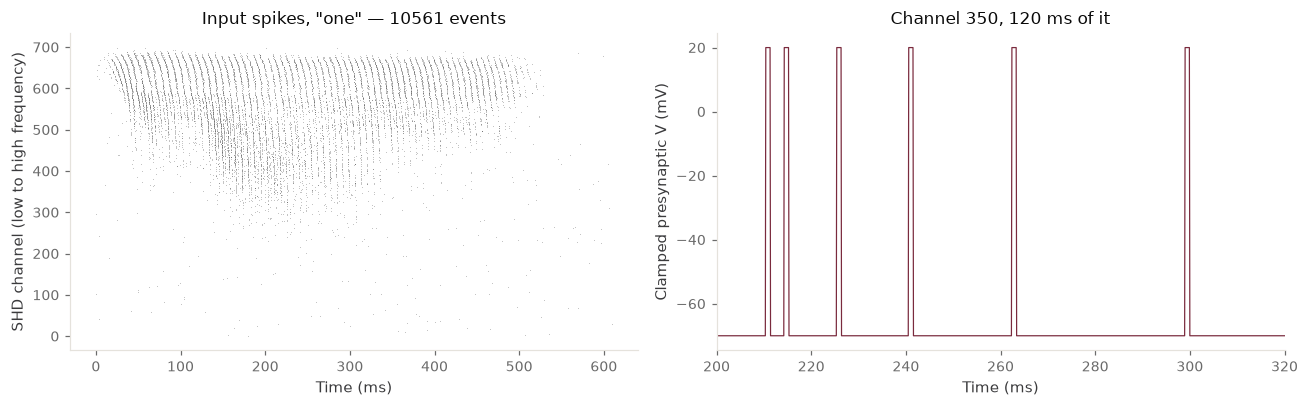

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

ev = data.events(shd, demo[0], t_max_ms=T_MAX)
axes[0].scatter(ev[:, 1], ev[:, 0], s=0.4, c=plotting.INK, marker=".", linewidths=0, alpha=0.7)
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("SHD channel (low to high frequency)")
axes[0].set_title(f'Input spikes, "{DIGITS[0]}" — {len(ev)} events')

axes[1].plot(np.arange(V_in.shape[2]) * SIM_DT, V_in[0, 350], lw=0.8, color=plotting.ACCENT)
axes[1].set_xlim(200, 320)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Clamped presynaptic V (mV)")
axes[1].set_title("Channel 350, 120 ms of it")
fig.tight_layout()
plotting.savefig(fig, "08_input", outdir="../plots")

## The layer

Each downstream cell is given a best frequency and draws `FAN_IN` presynaptic channels from a Gaussian around it — convergence onto a cell with a receptive field, which is the mechanism that pooling was standing in for, now inside the model rather than computed outside it.

Connections are `IonotropicSynapse`, so the drive is a conductance with a reversal potential. An injected current adds the same charge whatever the cell is doing; a conductance is divisive as well as additive and saturates as the membrane approaches `e_syn`, so a strongly depolarised cell is harder to drive further. Half of what a synapse does is missing from a current injection.

built in 22s: 1440 synapses onto 24 HH cells


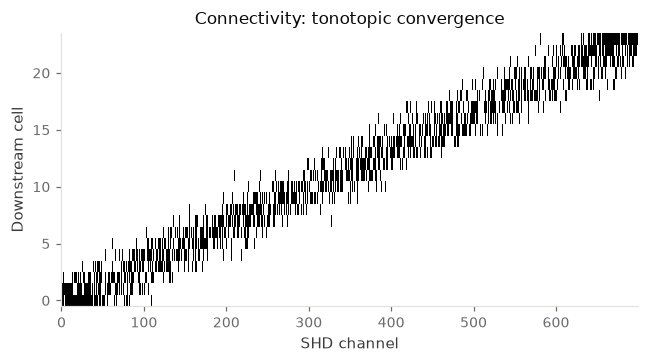

In [4]:
t0 = time.time()
M = spiking.tonotopic_connectivity(700, N_OUT, fan_in=FAN_IN, width=35.0,
                                   rng=np.random.default_rng(0))
net = spiking.build_layer(M, tau_syn_ms=5.0, e_syn_mV=0.0)
n_edges = len(net.edges)
sim = spiking.make_simulator(net, n_in=700, dt_ms=SIM_DT)
run = jax.jit(jax.vmap(sim, in_axes=(None, 0)))
print(f"built in {time.time() - t0:.0f}s: {n_edges} synapses onto {N_OUT} HH cells")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.imshow(M.T, aspect="auto", origin="lower", cmap="Greys", interpolation="nearest")
ax.set_xlabel("SHD channel")
ax.set_ylabel("Downstream cell")
ax.set_title("Connectivity: tonotopic convergence")
fig.tight_layout()

In [5]:
G_SYN = 3e-4   # uS per synapse

t0 = time.time()
V = np.asarray(run(jnp.full((n_edges,), G_SYN), jnp.array(V_in)))
print(f"{len(demo)} trials of {T_MAX:.0f} ms simulated in {time.time() - t0:.0f}s "
      f"(includes compilation) -> {V.shape}")
print(f"mean output rate {spiking.firing_rates(V, SIM_DT).mean():.1f} Hz")

4 trials of 700 ms simulated in 13s (includes compilation) -> (4, 24, 7001)
mean output rate 19.9 Hz


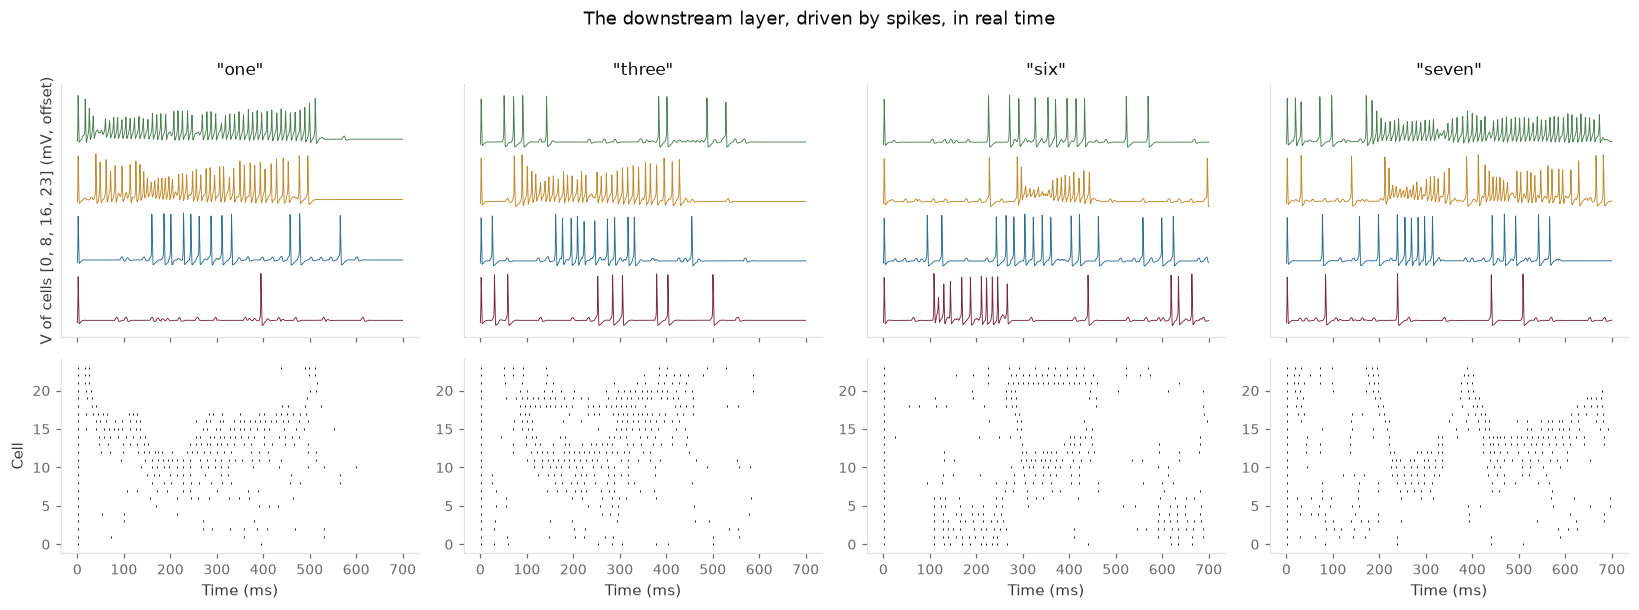

In [6]:
tt = np.arange(V.shape[2]) * SIM_DT
fig, axes = plt.subplots(2, len(DIGITS), figsize=(15, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1]})
shown = [0, N_OUT // 3, 2 * N_OUT // 3, N_OUT - 1]      # spread over the tonotopic axis
for j, word in enumerate(DIGITS):
    for k, i in enumerate(shown):
        axes[0, j].plot(tt, V[j, i] + k * 130, lw=0.6)
    axes[0, j].set_title(f'"{word}"')
    axes[0, j].set_yticks([])
    sp = spiking.detect_spikes(V[j], threshold=0.0)
    cell, step = np.nonzero(sp)
    axes[1, j].scatter(step * SIM_DT, cell, s=3, c=plotting.INK, marker="|", linewidths=0.6)
    axes[1, j].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel(f"V of cells {shown} (mV, offset)")
axes[1, 0].set_ylabel("Cell")
fig.suptitle("The downstream layer, driven by spikes, in real time", y=1.0)
fig.tight_layout()
plotting.savefig(fig, "08_spiking_layer", outdir="../plots")

Different digits drive different patterns across the tonotopic axis, structured rather than a uniform increase in rate. There is no learning here yet and no recurrence, so every cell is a weighted spike counter over its own frequency neighbourhood. Whether the patterns are *separable* is a question for notebook 9, which measures it.

The vertical line of spikes at *t* = 0 in every raster is not a response to anything: the cells start away from rest and each fires once as the integrator settles. It is identical on every trial, so it carries no class information, but it is real output in the first analysis bin and any serious analysis should discard the first 50 ms.

## The one parameter that decides whether any of this works

`G_SYN` is the maximal conductance of a single synapse. Too small and the layer barely responds; large enough and the rate stops rising and then *falls*, as sustained depolarisation leaves sodium channels inactivated — the beginning of depolarisation block. Watch the median membrane potential in the last column climb as that happens.

,mean rate (Hz),slowest cell (Hz),median V (mV)
gS (uS),,,
1e-05,1.43,1.43,-64.970001
1e-04,17.32,1.43,-64.970001
3e-04,19.67,6.43,-64.970001
1e-03,25.60,10.00,-64.970001
1e-02,19.29,5.71,-62.090000
3e-02,14.26,4.29,-55.090000


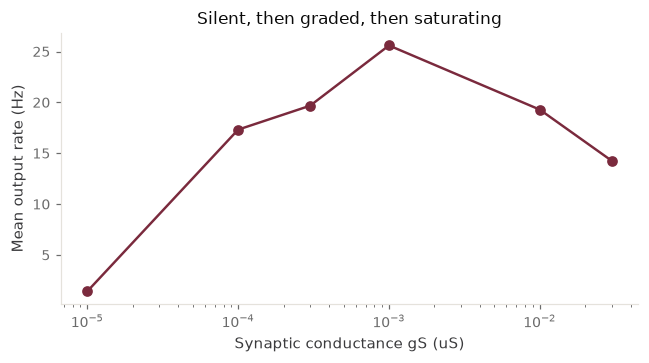

In [7]:
rows = []
for g in [1e-5, 1e-4, 3e-4, 1e-3, 1e-2, 3e-2]:
    Vg = np.asarray(run(jnp.full((n_edges,), g), jnp.array(V_in[:2])))
    r = spiking.firing_rates(Vg, SIM_DT)
    rows.append({"gS (uS)": f"{g:.0e}", "gS": g, "mean rate (Hz)": r.mean(),
                 "slowest cell (Hz)": r.mean(0).min(), "median V (mV)": np.median(Vg)})
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(sweep["gS"], sweep["mean rate (Hz)"], marker="o", color=plotting.ACCENT)
ax.set_xscale("log")
ax.set_xlabel("Synaptic conductance gS (uS)")
ax.set_ylabel("Mean output rate (Hz)")
ax.set_title("Silent, then graded, then saturating")
fig.tight_layout()
plotting.savefig(fig, "08_gain", outdir="../plots")

sweep.drop(columns="gS").set_index("gS (uS)").round(2)

Two things follow. The response is not monotone, so "stronger input, stronger output" has to be checked rather than assumed. And `G_SYN` was picked off this curve at a value where the cells fire in a plausible range; nothing in the data set it, so a result that holds only at one point of the sweep is a result about that point.

## What Part 1 costs, and why Part 2 exists

One trial of 700 ms at `dt = 0.1 ms` is 7000 integration steps, and a forward pass takes about a second once compiled. A *gradient* through those steps needs `checkpoint_lengths` to fit in memory and costs roughly ten times as much, so one epoch over a few hundred trials is tens of minutes — affordable for running the model, not for training it inside a teaching notebook. Part 2 buys a factor of forty by shrinking the problem.

---

# Part 2 · The reduced pipeline, and training through the simulator

```
SHD spikes  ->  exponential filter  ->  tonotopic pooling  ->  time compression  ->  injected current  ->  HH layer  ->  readout
   700 ch          continuous            24 bands             120 steps            trainable W          6 cells      4 classes
```

Four reductions, each sound as arithmetic and wrong as biology. State all four in your report:

| Step | What it buys | What it destroys |
|---|---|---|
| Exponential filter, `tau = 25 ms` | a continuous signal you can inject | spike timing below ~25 ms; the filter now does the temporal integration the membrane was supposed to do |
| Pooling to 24 bands | 29× fewer input channels | the identity of individual bushy cells; a band is a mixture, and convergence in a real circuit happens *at* the synapse, not before it |
| Compression to 120 steps at `dt = 0.5 ms` | 116× fewer integration steps | the relation between stimulus timescales and membrane timescales — the circuit hears the word played ~12× fast |
| Current injection instead of conductance | a differentiable scalar per cell per step | the reversal potential, and therefore the divisive half of what a synapse does |

The last one is the most consequential and the least visible. Everything below is downstream of it.

In [8]:
N_BANDS, N_CELLS, N_STEPS, DT = 24, 6, 120, 0.5
N_PER = 40

idx = np.concatenate([
    rng.choice(np.flatnonzero(shd.labels == data.DIGIT_KEYS.index(d)), N_PER, replace=False)
    for d in DIGITS
])
Xr, y_raw, _ = data.build_design_matrix(shd, bin_ms=4.0, t_max_ms=800.0, trials=idx)
y = np.searchsorted(np.unique(y_raw), y_raw)

B = filters.filter_spikes(Xr, "exponential", tau_ms=25.0, dt_ms=4.0)
B = filters.pool_channels(B, N_BANDS)
B = filters.resample_time(B, N_STEPS)
B = B / (B.std() + 1e-9)

print(f"drive: {B.shape} = (trials, bands, steps), {len(DIGITS)} classes, "
      f"chance = {1 / len(DIGITS):.2f}")

drive: (160, 24, 120) = (trials, bands, steps), 4 classes, chance = 0.25


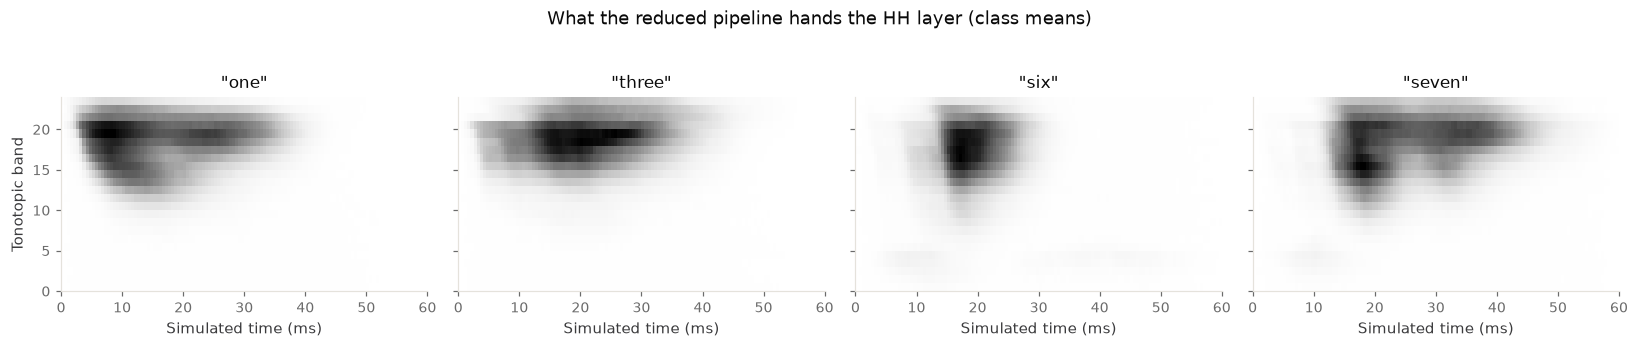

In [9]:
fig, axes = plt.subplots(1, len(DIGITS), figsize=(15, 3), sharey=True)
for ax, d in zip(axes, DIGITS):
    ax.imshow(B[y == DIGITS.index(d)].mean(0), aspect="auto", origin="lower", cmap="Greys",
              extent=[0, N_STEPS * DT, 0, N_BANDS], interpolation="nearest")
    ax.set_title(f'"{d}"')
    ax.set_xlabel("Simulated time (ms)")
axes[0].set_ylabel("Tonotopic band")
fig.suptitle("What the reduced pipeline hands the HH layer (class means)", y=1.04)
fig.tight_layout()
plotting.savefig(fig, "08_drive", outdir="../plots")

Compare that with the input raster in Part 1. It is the same word, and it is a different object.

## A second, smaller layer

Six single-compartment Hodgkin–Huxley neurons with no synapses at all — the current goes straight into the membrane. Every channel parameter is the JAXley default.

In [10]:
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=1)
inj = jx.Network([jx.Cell(branch, parents=[-1]) for _ in range(N_CELLS)])
inj.insert(HH())
inj.set("radius", 10.0)
inj.set("length", 10.0)
inj.set("axial_resistivity", 100.0)
inj.record("v", verbose=False)


def run_injected(currents):
    """currents: (N_CELLS, N_STEPS) in nA -> voltages (N_CELLS, N_STEPS+1) in mV."""
    ds = None
    for i in range(N_CELLS):
        ds = inj.cell(i).branch(0).comp(0).data_stimulate(currents[i], data_stimuli=ds)
    return jx.integrate(inj, data_stimuli=ds, delta_t=DT, t_max=(N_STEPS - 1) * DT)

`data_stimulate` inserts the current **inside** the traced computation, which is what makes the current — and therefore anything upstream of it — differentiable. That is the whole trick, and it is the same trick `spiking.make_simulator` uses for the synaptic conductances in Part 1.

## Making it trainable

Trainable parameters:

- `W` — how each tonotopic band drives each cell, `(6, 24)`
- `bias` — a constant background current per cell
- `Wout, bout` — a linear readout on the features below

Features are the **mean membrane voltage of each cell in four time windows**, so 6 × 4 = 24 numbers per trial. They are scaled by a fixed physical constant rather than by batch statistics — using batch mean and standard deviation here leaks test information and makes the accuracy jump around.

In [11]:
N_WIN = 4


def features(v):
    v = v[:, 1:]
    w = v.reshape(N_CELLS, N_WIN, -1).mean(axis=2)
    return (w.reshape(-1) + 60.0) / 20.0        # mV -> O(1), fixed scaling


def forward(p, b):
    current = jnp.einsum("nb,bt->nt", p["W"], b) + p["bias"][:, None]
    return features(run_injected(current))


batched = jax.vmap(forward, in_axes=(None, 0))


def loss_fn(p, bb, yy):
    logits = batched(p, bb) @ p["Wout"] + p["bout"]
    return optax.softmax_cross_entropy_with_integer_labels(logits, yy).mean(), logits


k1, k2 = jax.random.split(jax.random.PRNGKey(0))
params = {
    "W":    jax.random.normal(k1, (N_CELLS, N_BANDS)) * 0.05,
    "bias": jnp.full((N_CELLS,), 0.02),
    "Wout": jax.random.normal(k2, (N_CELLS * N_WIN, len(DIGITS))) * 0.1,
    "bout": jnp.zeros(len(DIGITS)),
}
print("trainable:", {k: tuple(v.shape) for k, v in params.items()},
      "->", sum(v.size for v in params.values()), "parameters")

trainable: {'W': (6, 24), 'bias': (6,), 'Wout': (24, 4), 'bout': (4,)} -> 250 parameters


### Gradient clipping is not optional here

Backpropagating through 120 steps of sodium and potassium kinetics produces occasional enormous gradients: when a small weight change moves a cell across spike threshold, the loss surface has something close to a discontinuity.

Without clipping the training curve is a trap. It climbs to about 0.95 test accuracy by epoch 20, holds for ten epochs, and then one oversized step sends the membrane somewhere the integrator cannot follow — the loss becomes NaN, every parameter follows it, and the remaining epochs sit at chance with no error raised. `optax.clip_by_global_norm` bounds the step and the learning rate drops from 3e-2 to 1e-2. The largest gradient norm per epoch is recorded below; the biggest single batch here is around fifty times the clip threshold.

Differentiating through a spiking model fails by looking converged rather than by crashing.

In [12]:
perm = rng.permutation(len(y))
n_train = int(0.75 * len(y))
tr, te = perm[:n_train], perm[n_train:]
Btr, ytr = jnp.array(B[tr]), jnp.array(y[tr])
Bte, yte = jnp.array(B[te]), jnp.array(y[te])

opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-2))
state = opt.init(params)


@jax.jit
def train_step(p, s, bb, yy):
    (l, _), g = jax.value_and_grad(loss_fn, has_aux=True)(p, bb, yy)
    updates, s = opt.update(g, s, p)
    return optax.apply_updates(p, updates), s, l, optax.global_norm(g)


@jax.jit
def accuracy(p, bb, yy):
    _, logits = loss_fn(p, bb, yy)
    return jnp.mean(jnp.argmax(logits, -1) == yy)

In [13]:
BATCH, EPOCHS = 24, 40
history = []
t0 = time.time()
for epoch in range(EPOCHS):
    order = rng.permutation(len(tr))
    peak_g = 0.0
    for i in range(0, len(tr) - BATCH + 1, BATCH):
        j = order[i:i + BATCH]
        params, state, loss, gnorm = train_step(params, state, Btr[j], ytr[j])
        peak_g = max(peak_g, float(gnorm))
    history.append({"epoch": epoch, "loss": float(loss), "max_grad_norm": peak_g,
                    "train": float(accuracy(params, Btr, ytr)),
                    "test": float(accuracy(params, Bte, yte))})
hist = pd.DataFrame(history)
print(f"trained in {time.time() - t0:.0f}s")
print(f"final: train {hist['train'].iloc[-1]:.3f}   test {hist['test'].iloc[-1]:.3f}   "
      f"chance {1 / len(DIGITS):.2f}")
print(f"gradient norm: median over epochs {hist['max_grad_norm'].median():.2f}, "
      f"largest {hist['max_grad_norm'].max():.1f} — the clip threshold is 1.0")

trained in 47s
final: train 1.000   test 0.975   chance 0.25
gradient norm: median over epochs 3.04, largest 51.3 — the clip threshold is 1.0


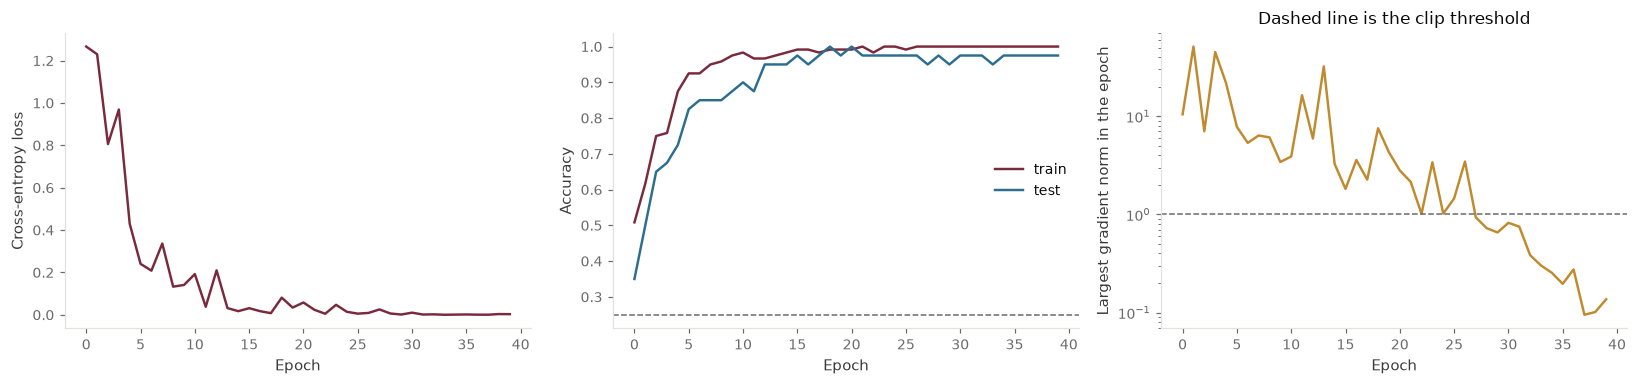

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(hist["epoch"], hist["loss"], color=plotting.ACCENT)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[1].plot(hist["epoch"], hist["train"], label="train", color=plotting.ACCENT)
axes[1].plot(hist["epoch"], hist["test"], label="test", color=plotting.PALETTE[1])
axes[1].axhline(1 / len(DIGITS), ls="--", lw=1, color=plotting.INK_MUTED)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
axes[2].plot(hist["epoch"], hist["max_grad_norm"], color=plotting.PALETTE[2])
axes[2].axhline(1.0, ls="--", lw=1, color=plotting.INK_MUTED)
axes[2].set_yscale("log")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Largest gradient norm in the epoch")
axes[2].set_title("Dashed line is the clip threshold")
fig.tight_layout()
plotting.savefig(fig, "08_training", outdir="../plots")

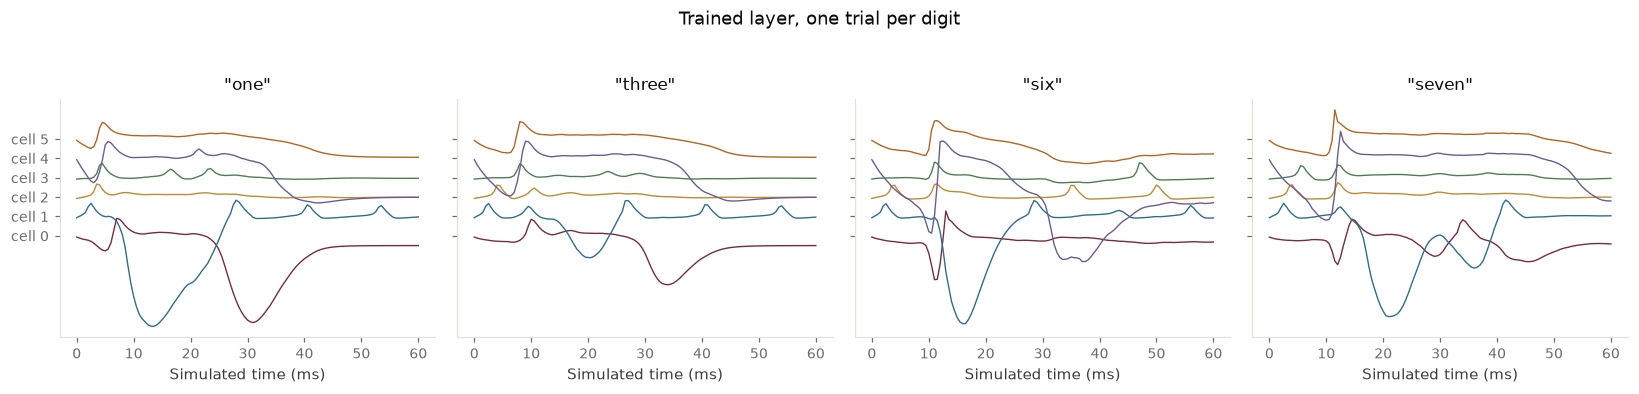

In [15]:
ex = {d: int(np.flatnonzero(y == i)[0]) for i, d in enumerate(DIGITS)}
fig, axes = plt.subplots(1, len(DIGITS), figsize=(15, 3.4), sharey=True)
for ax, (word, trial) in zip(axes, ex.items()):
    cur = jnp.einsum("nb,bt->nt", params["W"], jnp.array(B[trial])) + params["bias"][:, None]
    v = np.asarray(run_injected(cur))
    for i in range(N_CELLS):
        ax.plot(np.arange(v.shape[1]) * DT, v[i] + i * 130, lw=0.9)
    ax.set_title(f'"{word}"')
    ax.set_xlabel("Simulated time (ms)")
axes[0].set_yticks([i * 130 - 60 for i in range(N_CELLS)])
axes[0].set_yticklabels([f"cell {i}" for i in range(N_CELLS)])
fig.suptitle("Trained layer, one trial per digit", y=1.04)
fig.tight_layout()
plotting.savefig(fig, "08_trained_traces", outdir="../plots")

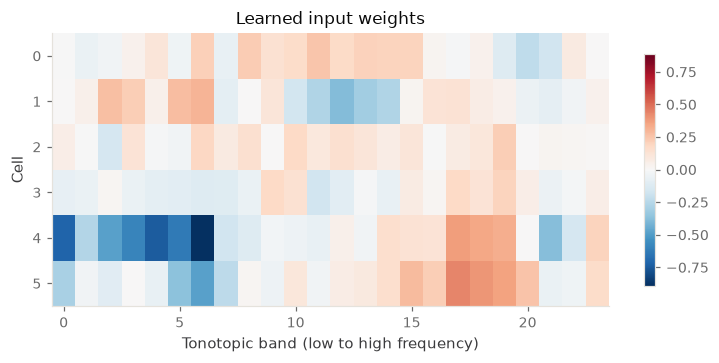

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.4))
im = ax.imshow(np.asarray(params["W"]), aspect="auto", cmap="RdBu_r",
               vmin=-np.abs(params["W"]).max(), vmax=np.abs(params["W"]).max())
ax.set_xlabel("Tonotopic band (low to high frequency)")
ax.set_ylabel("Cell")
ax.set_title("Learned input weights")
fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout()

Each cell has learned a weighting over frequency bands — a crude receptive field, arrived at by gradient descent rather than assigned as it was in Part 1. Whether it is smooth over frequency, or scattered, tells you whether the task rewarded tonotopic structure.

## The control that matters

The layer classifies well, but a linear readout on the input the layer was given, with no biophysics anywhere, is the comparison that says whether the HH neurons contributed anything.

In [17]:
from sklearn.linear_model import RidgeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Same four time windows, applied to the drive itself.
lin_feat = B.reshape(len(B), N_BANDS, N_WIN, -1).mean(axis=3).reshape(len(B), -1)
clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=1.0)).fit(lin_feat[tr], y[tr])
lin_acc = clf.score(lin_feat[te], y[te])

print(f"HH layer + readout    {hist['test'].iloc[-1]:.3f}   ({N_CELLS * N_WIN} features)")
print(f"linear on the input   {lin_acc:.3f}   ({lin_feat.shape[1]} features)")
print(f"chance                {1 / len(DIGITS):.3f}")

HH layer + readout    0.975   (24 features)
linear on the input   0.975   (96 features)
chance                0.250


The comparison is not clean: the two readouts see different numbers of features, so a difference could be about dimensionality rather than biophysics. Matching them properly — project the input to 24 dimensions with PCA, or give the HH layer more cells — is the first experiment anyone continuing this should run.

The two numbers come out equal, and equal is informative: the task is close to linearly separable from the filtered input already, so a biophysical layer has almost no room to help. The HH layer reaches the same accuracy from a quarter as many features, which is not the same as adding information.

To show that recurrence or biophysics adds something you have to pick a task where the linear baseline fails — one requiring memory across the trial, or a nonlinear combination of bands. Choosing that task is the real work in route B; getting an HH layer to train is the easy part.

Note also where the baseline is applied: to `B`, the filtered, pooled, compressed drive. Part 1's layer never sees that object, which is why notebook 9 runs the same control against the *spiking* model.

---

## What is wrong with each half

**Part 1 (spikes in).**

- **No recurrence.** 24 independent cells cannot do anything a pointwise nonlinearity could not; `jx.connect` and `IonotropicSynapse` between the output cells are the next step.
- **The receptive fields were assigned, not learned.** The Gaussian tonotopic fan-in is a hypothesis the data had no say in.
- **Synapses are excitatory only, and identical.** No inhibition, no short-term plasticity, one time constant.
- **The presynaptic voltage is a stand-in.** Its shape sets how much transmitter one spike releases, and nothing in SHD constrains it.

**Part 2 (reduced pipeline).** Everything in the table above, plus:

- **Training the input weights is not biology.** Backpropagation through 120 timesteps of channel kinetics asks *what would have to be true*; it is not a claim about how the circuit got that way.
- **Four digits, 160 trials.** A test set of 40. Treat the third decimal place as noise.

## Exercises

1. **Add recurrence to Part 1.** Connect the output cells with `IonotropicSynapse` and make some inhibitory (`e_syn = -80`). Does the output still track the input, and does the class structure survive?
2. **Train Part 1.** `spiking.make_simulator(..., checkpoints=[70, 100])` gives gradients through the real model. Train `G_SYN` per synapse, and time one epoch before committing to it.
3. **Make the control fair.** PCA the input to exactly `N_CELLS * N_WIN` dimensions before the linear readout in Part 2, and re-run the comparison.
4. **Train the biophysics.** `net.make_trainable("HH_gNa")` optimises channel conductances too. Where do they end up, and is the answer stable across seeds?
5. **Undo one reduction at a time.** Restore conductance-based input to Part 2, then real time, then the unpooled channels, measuring accuracy at each step. Which reduction was load-bearing?
6. **Break the linear baseline.** Design a task a linear readout cannot solve — classify a *sequence* of two digits, say — then ask again what the circuit adds.

Next: **[9 · The full spiking model](09_full_spiking_model.ipynb)** — the same layer, on the whole dataset, with the control route B asks for.